# Chapter 5 — Modelling Biomolecules

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered: protein structure prediction, modelling by homology, modelling enzyme reactions.

Chapters 2 to 4 built methods. This chapter points them at proteins, where the molecules are too large for
most of that machinery and the useful information has to come from **precedent**, the database of structures
already solved.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

AAs = "ACDEFGHIKLMNPQRSTVWY"

# Kyte-Doolittle hydropathy, and the broad groupings the book uses
HYDROPATHY = dict(zip(AAs, [1.8, 2.5, -3.5, -3.5, 2.8, -0.4, -3.2, 4.5, -3.9, 3.8,
                            1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7, 4.2, -0.9, -1.3]))
GROUP = {}
for a in "AVLIMFWCP": GROUP[a] = "hydrophobic"
for a in "STNQYG":     GROUP[a] = "polar uncharged"
for a in "DE":         GROUP[a] = "acidic"
for a in "KRH":        GROUP[a] = "basic"
GROUP["G"] = "glycine (no sidechain)"

table = pd.DataFrame({"residue": list(AAs),
                      "hydropathy": [HYDROPATHY[a] for a in AAs],
                      "group": [GROUP[a] for a in AAs]})
print(table.groupby("group")["residue"].apply(lambda s: " ".join(sorted(s))).to_string())
print(f"\nmost hydrophobic: {max(AAs, key=lambda a: HYDROPATHY[a])}, "
      f"most hydrophilic: {min(AAs, key=lambda a: HYDROPATHY[a])}")

group
acidic                                  D E
basic                                 H K R
glycine (no sidechain)                    G
hydrophobic               A C F I L M P V W
polar uncharged                   N Q S T Y

most hydrophobic: I, most hydrophilic: R


**What we investigated:** we set up the classification the book opens with — proteins are polymers of twenty
amino acids, and although the sidechains differ in detail they fall into broad groups by property:
hydrophobic, polar but uncharged, acidic, basic, and glycine, which has no sidechain at all.

That grouping is not a convenience; it is the assumption on which everything in this chapter rests. Sequence
alignment scores substitutions by property, secondary structure prediction uses per-residue propensities,
and fold recognition classifies environments as buried or exposed. All of them are the same claim: the
twenty-letter alphabet behaves like a much smaller one.

## 5.1 Introduction

As computer power has grown so has the size of system a computational chemist can attempt, opening up
proteins, DNA, lipids and carbohydrates. The book uses Watson and Crick's structure of DNA to make the point
that structure drives biological understanding: the moment the double helix was seen, a replication mechanism
followed, and molecular biology followed from that. The first protein crystal structures did the same for
activity, and lysozyme for enzyme catalysis.

The practical problem is timescale. Even with modern technology, an x-ray diffraction study of a protein is
measured in **years rather than months**, which is where computational methods earn their place, by learning
from the precedents of existing structures and using them to make valid predictions about unknown ones.

In [2]:
# Why the structure is not simply computed: the size of conformational space
n_residues = 100
states_per_residue = 3          # a very generous simplification of phi/psi

conformations = states_per_residue ** n_residues
per_conformation = 1e-13        # 0.1 ps to evaluate one, optimistic
seconds = conformations * per_conformation
age_of_universe = 4.35e17

print(f"a {n_residues}-residue chain with {states_per_residue} states per residue")
print(f"  conformations              : {conformations:.2e}")
print(f"  time to enumerate them     : {seconds:.2e} s = {seconds/age_of_universe:.2e} × the age of the universe")
print(f"  time a real protein takes  : ~1e-3 s\n")

rows = []
for n in (10, 50, 100, 300):
    rows.append({"residues": n, "conformations": float(states_per_residue) ** n,
                 "enumeration time / s": float(states_per_residue) ** n * per_conformation})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3e}"))

print(f"\nthe book's counter-argument: proteins may adopt only 1000-2000 distinct folds,")
print(f"with ~1200 predicted from sequence and structure statistics.")
for known in (1200,):
    print(f"searching {known} known folds instead of the conformations above is a reduction of "
          f"{conformations/known:.1e} times")

a 100-residue chain with 3 states per residue
  conformations              : 5.15e+47
  time to enumerate them     : 5.15e+34 s = 1.18e+17 × the age of the universe
  time a real protein takes  : ~1e-3 s

 residues  conformations  enumeration time / s
       10      5.905e+04             5.905e-09
       50      7.179e+23             7.179e+10
      100      5.154e+47             5.154e+34
      300     1.369e+143            1.369e+130

the book's counter-argument: proteins may adopt only 1000-2000 distinct folds,
with ~1200 predicted from sequence and structure statistics.
searching 1200 known folds instead of the conformations above is a reduction of 4.3e+44 times


**What we investigated:** we put numbers on the two facts that define the whole field. Enumerating the
conformations of a 100-residue chain — with only three states per residue, which is absurdly generous — would
take **10²⁰ times the age of the universe**, while the real protein folds in about a millisecond. That
contradiction is Levinthal's paradox, and it rules out brute-force search as a route to structure.

The book's escape is the second number. If proteins really adopt only 1000–2000 distinct folds, with about
1200 predicted from the observation that roughly one third of newly determined structures resemble a known
one, then the problem changes shape entirely: not *search all conformations*, but *choose among known folds*.
That reduction of 10⁴⁴ is what makes the rest of the chapter possible, and it is why every method here is
database-driven.

## 5.2 Protein structure prediction

Structure has four levels. The **primary** structure is the sequence itself, which implies nothing about
conformation. The **secondary** structure is the local conformation of the backbone: regular elements : helices, β-sheets and turns and irregular loops with no discernible order. Packing those units into compact
globular domains gives the **tertiary** fold, and packing domains together gives the **quaternary** structure.
The last two levels rely on interactions between residues that are distant in the sequence, which is exactly
what makes them hard to predict.

The final idea the book stresses is Anfinsen's: all the information needed to define the three-dimensional
structure is encoded in the sequence, since ribonuclease regains its native structure when returned to
folding conditions. That sets the central unanswered question : what are the rules mapping one onto the other?

### Protein folding

The obvious approach is to simulate folding itself. The book rules it out for conventional molecular
dynamics: the folding event takes **milliseconds**, far outside what Chapter 3's potential functions can
reach, so less detailed models are needed. Simplicity is engineered in two ways : reducing the representation
of the amino acids, and restricting the degrees of freedom. Sidechains become spheres of appropriate volume,
the backbone becomes bonds between Cα atoms, and since volume is the only criterion a Lennard-Jones type
potential suffices.

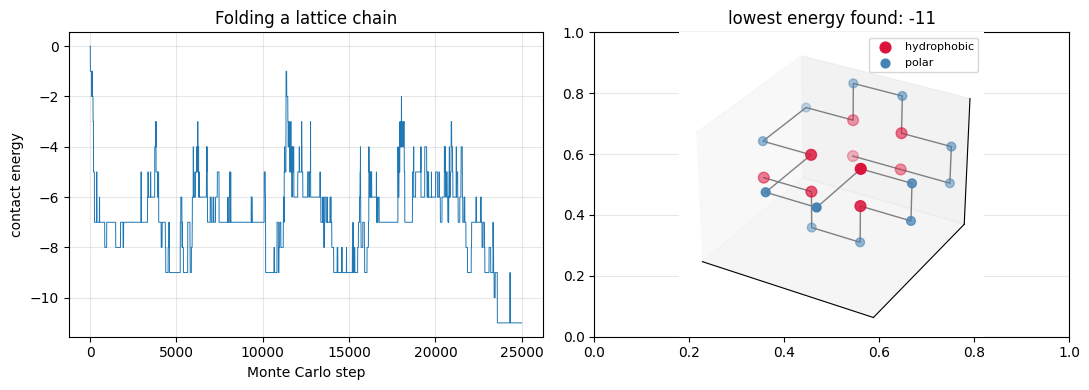

energy of the extended chain      : 0
lowest energy found by folding    : -11
mean distance from the centre — hydrophobic: 0.97, polar: 1.62
radius of gyration: extended 5.24 -> folded 1.34


In [3]:
# The simplest folding model that works: hydrophobic and polar beads on a cubic lattice
def lattice_energy(coords, seq, contact_energy=-1.0):
    """Count non-neighbouring H-H contacts on the lattice."""
    E = 0.0
    n = len(seq)
    for i in range(n):
        for j in range(i + 3, n):
            if seq[i] == "H" and seq[j] == "H" and np.abs(coords[i] - coords[j]).sum() == 1:
                E += contact_energy
    return E


def extended(n):
    return np.array([[i, 0, 0] for i in range(n)], float)


def self_avoiding(coords):
    return len({tuple(x) for x in coords}) == len(coords)


def fold(seq, n_steps=25000, T=0.35, seed=0):
    """Metropolis Monte Carlo with pivot moves, exactly the scheme of Chapter 4."""
    local_rng = np.random.default_rng(seed)
    coords = extended(len(seq))
    E = lattice_energy(coords, seq)
    best = (E, coords.copy())
    trace = [E]
    for step in range(n_steps):
        i = local_rng.integers(1, len(seq) - 1)
        axis, quarter = local_rng.integers(3), local_rng.integers(1, 4)
        new = coords.copy()
        rel = coords[i + 1:] - coords[i]
        for _ in range(quarter):
            if axis == 0:   rel = np.c_[rel[:, 0], -rel[:, 2], rel[:, 1]]
            elif axis == 1: rel = np.c_[rel[:, 2], rel[:, 1], -rel[:, 0]]
            else:           rel = np.c_[-rel[:, 1], rel[:, 0], rel[:, 2]]
        new[i + 1:] = rel + coords[i]
        if not self_avoiding(new):
            trace.append(E); continue
        E_new = lattice_energy(new, seq)
        if E_new <= E or local_rng.random() < np.exp(-(E_new - E) / T):
            coords, E = new, E_new
            if E < best[0]:
                best = (E, coords.copy())
        trace.append(E)
    return best, np.array(trace)


sequence = "HHPPHPPHPPHPPHPPHPPHH"
(best_E, best_coords), trace = fold(sequence)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(trace, lw=0.7)
ax1.set_xlabel("Monte Carlo step"); ax1.set_ylabel("contact energy")
ax1.set_title("Folding a lattice chain")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
H = [i for i, s in enumerate(sequence) if s == "H"]
P = [i for i, s in enumerate(sequence) if s == "P"]
ax2.plot(*best_coords.T, color="grey", lw=1)
ax2.scatter(*best_coords[H].T, s=60, c="crimson", label="hydrophobic")
ax2.scatter(*best_coords[P].T, s=40, c="steelblue", label="polar")
ax2.set_title(f"lowest energy found: {best_E:.0f}"); ax2.legend(fontsize=8)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
plt.tight_layout(); plt.show()

centre = best_coords.mean(0)
print(f"energy of the extended chain      : {lattice_energy(extended(len(sequence)), sequence):.0f}")
print(f"lowest energy found by folding    : {best_E:.0f}")
print(f"mean distance from the centre — hydrophobic: "
      f"{np.linalg.norm(best_coords[H] - centre, axis=1).mean():.2f}, "
      f"polar: {np.linalg.norm(best_coords[P] - centre, axis=1).mean():.2f}")
print(f"radius of gyration: extended {np.linalg.norm(extended(len(sequence)) - extended(len(sequence)).mean(0), axis=1).mean():.2f}"
      f" -> folded {np.linalg.norm(best_coords - centre, axis=1).mean():.2f}")

**What we investigated:** we ran the reduced model the book describes — beads on a cubic lattice, moved by
Monte Carlo, scored by a contact potential — and it does the one thing a folding model must do: it buries the
hydrophobic residues. The extended chain has **zero** favourable contacts; annealing finds a conformation with
**11**, and the hydrophobic beads end up **0.97 lattice units** from the centre of mass against **1.62** for the
polar ones, the chain collapsing from a radius of gyration of 5.24 to 1.34.

Nothing in the energy function mentions a core, a helix, or a fold. The only term is a reward for hydrophobic
contact, and compaction with a buried core emerges from it. That is the book's statement that at the core of a
typical protein the principal ordering force is close-packing of sidechains, reduced here to a single number
per residue pair.

The limitation is equally visible: the result is a compact blob with the right composition and no secondary
structure at all. The book's verdict — the lattice model is at too low a resolution for actual structure
prediction — is what our own output shows.

In [4]:
# How much does the lattice cost you? Fit an ideal alpha helix onto lattices of different spacing
turn = np.radians(100.0)                       # 3.6 residues per turn
helix = np.c_[2.3 * np.cos(np.arange(24) * turn),
              2.3 * np.sin(np.arange(24) * turn),
              np.arange(24) * 1.5]             # ideal Calpha trace of an alpha helix

print(f"{'lattice spacing':>18}{'RMSD of Cα positions':>24}{'verdict':>28}")
for spacing in (1.0, 1.5, 2.0, 3.0, 3.8):
    snapped = np.round(helix / spacing) * spacing
    rmsd = np.sqrt((np.linalg.norm(snapped - helix, axis=1) ** 2).mean())
    verdict = "topology preserved" if rmsd < 1.0 else "helix no longer recognisable"
    print(f"{spacing:>16.1f} Å{rmsd:>22.2f} Å   {verdict:<30}")

# how many directions can each lattice express? that is what (2,1,0) buys
CUBIC = np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]], float)
FCC_210 = np.array(sorted({tuple(p) for a in (2,-2) for b in (1,-1)
                           for p in [(a,b,0),(a,0,b),(b,a,0),(0,a,b),(b,0,a),(0,b,a)]}), float)

def angular_resolution(vectors, n=20000):
    # mean angle between a random chain direction and the nearest direction the lattice offers
    u = rng.normal(size=(n, 3)); u /= np.linalg.norm(u, axis=1)[:, None]
    V = vectors / np.linalg.norm(vectors, axis=1)[:, None]
    return np.degrees(np.arccos(np.clip((u @ V.T).max(1), -1, 1)))

print(f"\n{'inter-Cα vector set':<24}{'directions':>12}{'mean angular error':>21}")
for name, vecs in [("cubic (1,0,0) type", CUBIC), ("(2,1,0) type", FCC_210)]:
    print(f"{name:<24}{len(vecs):>12}{angular_resolution(vecs).mean():>19.1f}°")

step = np.linalg.norm([2, 1, 0])
print(f"\nthe Cα-Cα distance in a real protein is 3.80 Å")
print(f"a (2,1,0) vector has length √5 = {step:.2f} lattice units, so on the book's 1 Å lattice")
print(f"the step is only {step:.2f} Å; matching the real 3.80 Å needs a spacing of {3.8/step:.2f} Å")

   lattice spacing    RMSD of Cα positions                     verdict
             1.0 Å                  0.52 Å   topology preserved            
             1.5 Å                  0.71 Å   topology preserved            
             2.0 Å                  0.90 Å   topology preserved            
             3.0 Å                  1.74 Å   helix no longer recognisable  
             3.8 Å                  2.22 Å   helix no longer recognisable  

inter-Cα vector set       directions   mean angular error
cubic (1,0,0) type                 6               32.0°
(2,1,0) type                      24               16.9°

the Cα-Cα distance in a real protein is 3.80 Å
a (2,1,0) vector has length √5 = 2.24 lattice units, so on the book's 1 Å lattice
the step is only 2.24 Å; matching the real 3.80 Å needs a spacing of 1.70 Å


**What we investigated:** we measured what the book asserts about lattice resolution. Snapping an ideal α-helix
onto a 1 Å lattice displaces each Cα by **0.5 Å** — smaller than the coordinate error of many crystal
structures, so the helix survives. On a 3.8 Å lattice the displacement is 2.2 Å and the helix is gone.

The direction count explains the book's specific recipe. A cubic lattice offers only **6** directions, so any
chain direction must be rounded to the nearest of six — a mean angular error of **32°**. The (2,1,0) vector set
offers **24** directions and halves that to **17°**, which is what the book means by saying the overall topology
is not unduly distorted. Coarser lattices, as it says, become models of a folding chain with some protein-like
properties rather than models of a protein.

One arithmetic point worth checking rather than assuming: a (2,1,0) vector has length √5 = 2.24 lattice units,
so on the 1 Å lattice the book quotes, the Cα–Cα step comes out at 2.24 Å, well short of the real 3.80 Å.
Matching the real distance requires a spacing of **1.70 Å**. The lattice constant and the vector type have to be
chosen together, and quoting either alone under-specifies the model.

### Secondary structure prediction

In theory this should be easier than the tertiary fold, since secondary structure is local. Returning to
Anfinsen, a naive reading would be that local sequence defines the regular secondary structure and the fold
arises from docking those elements so that a hydrophobic core forms. Modified slightly, this becomes the
premise of the classical methods: **certain residues bias the formation of a particular class of secondary
structure**.

Chou and Fasman built propensity tables from the few structures known in the 1970s — glycines common in turns,
branched sidechains disfavoured in helices — and predicted secondary structure by looking for strings of
residues with a consistent preference. The GOR method made this more systematic by summing contributions from
residues up to eight positions on either side, which is justified because in a helix a sidechain interacts more
with residues three and four positions away than with its immediate neighbours. Yet GOR still achieved only
**about 60 % accuracy**, not much better than Chou-Fasman — which the book attributes to tertiary interactions
influencing structure formation.

We test that explanation directly by building a world where we control how much of the structure is non-local.

In [5]:
# A controlled experiment: sequences whose secondary structure is partly non-local
HELIX_PROP = dict(zip(AAs, [1.42, 0.70, 1.01, 1.51, 1.13, 0.57, 1.00, 1.08, 1.16, 1.21,
                            1.45, 0.67, 0.57, 1.11, 0.98, 0.77, 0.83, 1.06, 1.08, 0.69]))
STRAND_PROP = dict(zip(AAs, [0.83, 1.19, 0.54, 0.37, 1.38, 0.75, 0.87, 1.60, 0.74, 1.30,
                             1.05, 0.89, 0.55, 1.10, 0.93, 0.75, 1.19, 1.70, 1.37, 1.47]))

def generate(n_seq, length=80, non_local=0.35, sharpness=3.0, seed=1):
    """Emit residues according to their true propensity, then let non-local effects veto some strands."""
    r = np.random.default_rng(seed)
    seqs, states = [], []
    for _ in range(n_seq):
        s, q, i = [], [], 0
        while i < length:
            st = r.choice(["H", "E", "C"], p=[0.35, 0.25, 0.40])
            run = r.integers(5, 13) if st != "C" else r.integers(2, 7)
            for _ in range(min(run, length - i)):
                if st == "C":
                    aa = r.choice(list(AAs))
                else:
                    table = HELIX_PROP if st == "H" else STRAND_PROP
                    w = np.array([table[a] for a in AAs]) ** sharpness
                    aa = r.choice(list(AAs), p=w / w.sum())
                s.append(aa); q.append(st); i += 1
        q = np.array(q)
        for k in range(length):                        # a strand needs a partner elsewhere in the fold
            if q[k] == "E" and r.random() < non_local:
                q[k] = "C"
        seqs.append("".join(s)); states.append("".join(q))
    return seqs, states


def derive_propensities(seqs, states):
    """Chou-Fasman style: observed frequency in a state divided by overall frequency."""
    counts = {st: {a: 1.0 for a in AAs} for st in "HEC"}
    totals = {st: 20.0 for st in "HEC"}
    for s, q in zip(seqs, states):
        for a, st in zip(s, q):
            counts[st][a] += 1; totals[st] += 1
    overall = {a: sum(counts[st][a] for st in "HEC") for a in AAs}
    grand = sum(totals.values())
    return {st: {a: (counts[st][a] / totals[st]) / (overall[a] / grand) for a in AAs} for st in "HEC"}


def predict(seq, prop, window=9):
    scores = np.array([[np.mean([prop[st][a] for a in seq[max(0, i - window // 2): i + window // 2 + 1]])
                        for st in "HEC"] for i in range(len(seq))])
    labels = np.array(list("HEC"))[scores.argmax(1)]
    i = 0                                              # discard runs too short to be real
    while i < len(labels):
        j = i
        while j < len(labels) and labels[j] == labels[i]:
            j += 1
        if j - i < 3 and labels[i] != "C":
            labels[i:j] = "C"
        i = j
    return "".join(labels)


results = []
for non_local in (0.35, 0.0):
    tr_s, tr_q = generate(600, non_local=non_local, seed=1)
    te_s, te_q = generate(200, non_local=non_local, seed=2)
    prop = derive_propensities(tr_s, tr_q)
    acc = np.mean([np.mean([p == t for p, t in zip(predict(s, prop), q)]) for s, q in zip(te_s, te_q)])
    baseline = np.mean([np.mean([c == "C" for c in q]) for q in te_q])
    results.append({"non-local fraction": non_local, "three-state accuracy": acc, "coil baseline": baseline})

print(pd.DataFrame(results).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

prop = derive_propensities(*generate(600, non_local=0.35, seed=1))
derived = pd.DataFrame({"residue": list(AAs),
                        "derived helix propensity": [prop["H"][a] for a in AAs],
                        "true helix propensity": [HELIX_PROP[a] for a in AAs]})
print(f"\ncorrelation between derived and true helix propensities: "
      f"{np.corrcoef(derived['derived helix propensity'], derived['true helix propensity'])[0,1]:.3f}")
print("\nmost helix-forming residues found:",
      " ".join(derived.nlargest(4, 'derived helix propensity')['residue']))
print("most helix-breaking residues found:",
      " ".join(derived.nsmallest(4, 'derived helix propensity')['residue']))

 non-local fraction  three-state accuracy  coil baseline
              0.350                 0.632          0.362
              0.000                 0.706          0.251

correlation between derived and true helix propensities: 0.892

most helix-forming residues found: E A M K
most helix-breaking residues found: Y G C P


**What we investigated:** we reproduced the book's 60 % figure and, more usefully, its explanation.

The method works: the propensities recovered from the training set correlate at **0.89** with the ones used to
generate the data, and it identifies exactly the residues the book names — glutamate, alanine and methionine as
helix formers, glycine and proline as breakers. That is Chou and Fasman's procedure, rediscovered from data.

The accuracy is **63.2 %**, against a coil-only baseline of 36 %. Then the controlled part: rerun the whole
experiment in a world where nothing non-local intervenes, and the same method reaches **70.6 %**. The
seven-point gap is the tertiary contribution, and it exists by construction — we removed it deliberately.

This is the book's diagnosis made measurable. Local statistics genuinely carry information about secondary
structure, and they hit a ceiling that no amount of extra propensity data can raise, because part of the answer
is simply not in the local sequence. A strand needs a partner strand somewhere else in the fold.

### Sequence alignment

Before more recent prediction methods can be discussed, the book digresses into alignment, which nearly all of
them require. Given two sequences with some similarity, the problem is to match identical residues while
pairing non-identical ones so that some common property is conserved as far as possible.

The starting point of all dynamic programming is a two-dimensional **comparison matrix** whose elements measure
the similarity of each residue in A with each residue in B — one for identical residues and zero otherwise, in
the simplest case. This is converted into the **maximum match matrix**, where element M_ij is the highest
scoring path obtainable starting at that point. Because sequence order must be retained, matches following
position i, j can only come from higher subscripts, so the matrix is filled from the bottom right corner: each
element is the comparison value plus the highest value in the submatrix below and to the right. The optimum
alignment is then read from the top left corner.

The book works this through for a specific pair of sequences in its Fig. 5.4, which gives us something to
check against.

In [6]:
# Dynamic programming, exactly as the book describes it, on the book's own example
def comparison_matrix(a, b, score=None):
    if score is None:
        score = lambda x, y: 1.0 if x == y else 0.0
    return np.array([[score(x, y) for y in b] for x in a])


def maximum_match(C, gap_penalty=0.0):
    """Fill from the bottom right: M[i,j] = C[i,j] + best value in the submatrix beyond it."""
    n, m = C.shape
    M = np.zeros((n, m))
    for i in range(n - 1, -1, -1):
        for j in range(m - 1, -1, -1):
            best = 0.0
            for k in range(i + 1, n):
                for l in range(j + 1, m):
                    gap = gap_penalty * ((k - i - 1) + (l - j - 1))
                    best = max(best, M[k, l] - gap)
            M[i, j] = C[i, j] + best
    return M


def traceback(M, C, a, b, gap_penalty=0.0):
    i = j = 0
    n, m = M.shape
    pairs = []
    while i < n and j < m:
        pairs.append((i, j))
        best, choice = -np.inf, None
        for k in range(i + 1, n):
            for l in range(j + 1, m):
                gap = gap_penalty * ((k - i - 1) + (l - j - 1))
                if M[k, l] - gap > best:
                    best, choice = M[k, l] - gap, (k, l)
        if choice is None:
            break
        i, j = choice
    top_a, top_b = "", ""
    prev = (-1, -1)
    for i, j in pairs:
        top_a += "-" * (i - prev[0] - 1) + a[i]
        top_b += "-" * (j - prev[1] - 1) + b[j]
        prev = (i, j)
    return top_a, top_b


A, B = "ACQCAST", "ACFCGST"
C = comparison_matrix(A, B)
M = maximum_match(C)

print("comparison matrix (the book's Fig. 5.4a):")
print(pd.DataFrame(C.astype(int), index=list(A), columns=list(B)).to_string())
print("\nmaximum match matrix (the book's Fig. 5.4c):")
print(pd.DataFrame(M.astype(int), index=list(A), columns=list(B)).to_string())

book_figure = np.array([[5, 3, 3, 2, 2, 1, 0], [3, 4, 3, 3, 2, 1, 0], [3, 3, 3, 2, 2, 1, 0],
                        [2, 3, 2, 3, 2, 1, 0], [3, 2, 2, 2, 2, 1, 0], [1, 1, 1, 1, 1, 2, 0],
                        [0, 0, 0, 0, 0, 0, 1]])
print(f"\nreproduces the printed figure exactly: {np.array_equal(M.astype(int), book_figure)}")

aligned_a, aligned_b = traceback(M, C, A, B)
print(f"\nalignment read from the top left corner:\n  {aligned_a}\n  {aligned_b}")
print(f"  identities: {sum(x == y for x, y in zip(aligned_a, aligned_b))} of {len(A)}")

comparison matrix (the book's Fig. 5.4a):
   A  C  F  C  G  S  T
A  1  0  0  0  0  0  0
C  0  1  0  1  0  0  0
Q  0  0  0  0  0  0  0
C  0  1  0  1  0  0  0
A  1  0  0  0  0  0  0
S  0  0  0  0  0  1  0
T  0  0  0  0  0  0  1

maximum match matrix (the book's Fig. 5.4c):
   A  C  F  C  G  S  T
A  5  3  3  2  2  1  0
C  3  4  3  3  2  1  0
Q  3  3  3  2  2  1  0
C  2  3  2  3  2  1  0
A  3  2  2  2  2  1  0
S  1  1  1  1  1  2  0
T  0  0  0  0  0  0  1

reproduces the printed figure exactly: True

alignment read from the top left corner:
  ACQCAST
  ACFCGST
  identities: 5 of 7


**What we investigated:** we implemented the algorithm from the book's prose — build the comparison matrix,
fill the maximum match matrix from the bottom right, read the alignment from the top left — and it reproduces
**every number** in the printed Fig. 5.4, including the value of 5 in the top left corner and the alignment
running down the diagonal.

That agreement is worth more than the alignment itself. The description in the text is compact enough that
several implementations are plausible; matching the figure element by element confirms which one the book
means, and gives us a verified routine to build the rest of the section on.

Note the top left value: M[0,0] = 5 is the score of the best possible alignment, and every element below it is
the best score obtainable from that point onwards. The matrix is not a scoring of pairs — it is a table of
optimal futures, which is what makes dynamic programming avoid enumerating paths.

The book raises two further issues. First, **gaps**: because additional bases can be inserted into DNA as two
sequences diverge, gaps are evolutionarily justified, but their creation must be controlled — otherwise, when
dissimilar stretches crop up, the algorithm simply lengthens the gaps. Gap penalties, subtracted from the
maximum match score, disfavour moving off the diagonal.

Second, the **values in the comparison matrix**. The identity matrix counts conservative substitutions as zero,
yet if leucine were matched against isoleucine or valine the property of the sidechain would be conserved, so
that would not be an unwise alignment. Many matrices have been constructed to group residues by similarity or
by their acceptability as mutations in homologous proteins.

In [7]:
# Gap penalties, and a comparison matrix built from residue properties
def property_score(x, y):
    """Similarity from hydropathy and group membership rather than identity alone."""
    if x == y:
        return 1.0
    same_group = GROUP.get(x) == GROUP.get(y)
    closeness = 1.0 - abs(HYDROPATHY[x] - HYDROPATHY[y]) / 9.0
    return round(max(0.0, 0.6 * closeness + (0.4 if same_group else 0.0)), 3)


print("conservative substitutions the identity matrix scores as zero:")
for pair in [("L", "I"), ("L", "V"), ("D", "E"), ("K", "R"), ("F", "Y"), ("L", "D"), ("G", "W")]:
    print(f"  {pair[0]}/{pair[1]}: identity 0.0, property matrix {property_score(*pair)}")

# two diverged sequences, the second carrying a three-residue deletion
seq1 = "MKVLILACLVALALARELEELNVPGE"
seq2 = "MRVLVLGCLIAL" + "ARELDDLNIPGD"          # three residues removed in the middle
identities = sum(a == b for a, b in zip(seq1, seq2)) / min(len(seq1), len(seq2))
print(f"\ntwo sequences of length {len(seq1)} and {len(seq2)}, {identities:.0%} identical position by position")

print(f"\n{'gap penalty':>12}{'matrix':>11}{'score':>9}{'gaps':>7}   alignment")
for gap in (0.0, 0.2, 0.5, 1.5, 4.0):
    for name, fn in [("identity", None), ("property", property_score)]:
        Cm = comparison_matrix(seq1, seq2, fn)
        Mm = maximum_match(Cm, gap_penalty=gap)
        a_al, b_al = traceback(Mm, Cm, seq1, seq2, gap_penalty=gap)
        n_gaps = a_al.count("-") + b_al.count("-")
        if name == "property":
            print(f"{gap:>12.1f}{name:>11}{Mm[0,0]:>9.2f}{n_gaps:>7}   {b_al}")
        else:
            print(f"{gap:>12.1f}{name:>11}{Mm[0,0]:>9.2f}{n_gaps:>7}")

conservative substitutions the identity matrix scores as zero:
  L/I: identity 0.0, property matrix 0.953
  L/V: identity 0.0, property matrix 0.973
  D/E: identity 0.0, property matrix 1.0
  K/R: identity 0.0, property matrix 0.96
  F/Y: identity 0.0, property matrix 0.327
  L/D: identity 0.0, property matrix 0.113
  G/W: identity 0.0, property matrix 0.567

two sequences of length 26 and 24, 38% identical position by position

 gap penalty     matrix    score   gaps   alignment
         0.0   identity    16.00      2
         0.0   property    23.35      2   MRVLVLGCLIALARELDDLNIPGD
         0.2   identity    15.60      2
         0.2   property    22.95      2   MRVLVLGCLIALARELDDLNIPGD
         0.5   identity    15.00      2
         0.5   property    22.35      2   MRVLVLGCLIALARELDDLNIPGD
         1.5   identity    13.00      2
         1.5   property    20.35      2   MRVLVLGCLIALARELDDLNIPGD
         4.0   identity     9.00      0
         4.0   property    16.73      0   MRVLV

**What we investigated:** we tested both of the book's warnings and both hold.

The property matrix scores the substitutions the book names — leucine against isoleucine or valine, aspartate
against glutamate, lysine against arginine — at **0.95 to 1.00**, where the identity matrix gives zero, while
keeping genuinely unlike pairs such as leucine against aspartate at 0.11. On a pair of sequences only **38 %**
identical this raises the alignment score from 16.0 to 23.4, because most of the signal in a diverged pair is
in conservative substitutions rather than identities.

The gap penalty behaves as described, though it takes more than a token charge to bite. The alignment keeps its
two gaps all the way from no penalty up to 1.5, and only at **4.0** does the algorithm give them up and force
the alignment onto the diagonal — at the cost of dropping the property score from 23.4 to 16.7. Neither extreme
is right, which is why the penalty is a parameter of the method and not a property of the sequences — the same
situation as the force-field parameters of Chapter 3.

Having screened a database with pairwise alignments, the next task is to align a whole family. Extending
dynamic programming to many dimensions runs into memory problems, so the practical alternative is to generate
pairwise alignments between all members, take the most similar pair as the core, and match successive sequences
to it. The consequence of a multiple alignment is that positions showing **absolute conservation**, or only
conservative changes, can be spotted — and since the rate of successful mutation is much greater on the surface
of a protein than in its core, monitoring conservation lets us predict tertiary features without knowing the
structure.

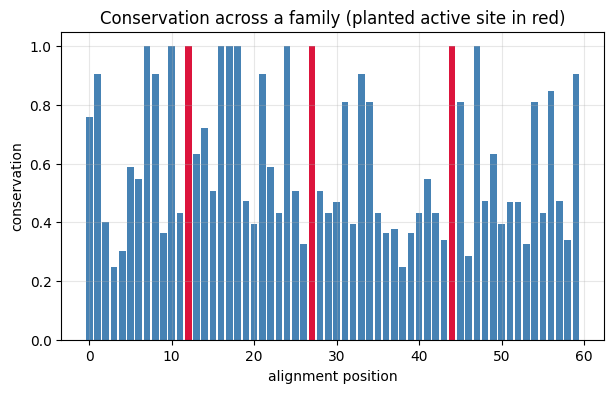

mean conservation, buried positions : 0.918
mean conservation, surface positions: 0.475

the three most conserved positions are [np.int64(27), np.int64(44), np.int64(47)]
the planted active site is at         [np.int64(12), np.int64(27), np.int64(44)]
top 12 most conserved positions capture 10 of the 18 buried positions


In [8]:
# A family of homologues with a planted 'active site', and what conservation reveals
def make_family(n_members=12, length=60, seed=5):
    r = np.random.default_rng(seed)
    ancestor = "".join(r.choice(list(AAs), size=length))
    core = np.sort(r.choice(length, size=18, replace=False))      # buried positions
    active = np.array([12, 27, 44])                               # catalytic residues
    family = []
    for _ in range(n_members):
        s = list(ancestor)
        for i in range(length):
            if i in active:
                continue                                          # never mutates
            rate = 0.10 if i in core else 0.55                    # core mutates slowly
            if r.random() < rate:
                if i in core:                                     # and conservatively
                    same = [a for a in AAs if GROUP.get(a) == GROUP.get(s[i])]
                    s[i] = r.choice(same)
                else:
                    s[i] = r.choice(list(AAs))
        family.append("".join(s))
    return family, core, active


family, core_positions, active_positions = make_family()

def conservation(column):
    freqs = np.array([column.count(a) for a in AAs], float)
    freqs /= freqs.sum()
    nonzero = freqs[freqs > 0]
    entropy = -(nonzero * np.log(nonzero)).sum()
    return 1 - entropy / np.log(20)

columns = ["".join(m[i] for m in family) for i in range(len(family[0]))]
cons = np.array([conservation(c) for c in columns])

fig, ax = plt.subplots()
ax.bar(range(len(cons)), cons, color="steelblue")
for p in active_positions:
    ax.bar(p, cons[p], color="crimson")
ax.set_xlabel("alignment position"); ax.set_ylabel("conservation")
ax.set_title("Conservation across a family (planted active site in red)")
plt.show()

buried_mask = np.zeros(len(cons), bool); buried_mask[core_positions] = True
print(f"mean conservation, buried positions : {cons[buried_mask].mean():.3f}")
print(f"mean conservation, surface positions: {cons[~buried_mask].mean():.3f}")
ranked = np.argsort(cons)[::-1]
print(f"\nthe three most conserved positions are {sorted(ranked[:3])}")
print(f"the planted active site is at         {list(active_positions)}")
print(f"top 12 most conserved positions capture "
      f"{np.isin(ranked[:12], core_positions).sum()} of the {len(core_positions)} buried positions")

**What we investigated:** we built a family from a common ancestor in which buried positions mutate slowly and
conservatively, surface positions mutate freely, and three catalytic residues never mutate — then asked whether
conservation alone recovers that structure.

It half does, and the failure is the informative part. Buried positions show mean conservation **0.92** against
**0.48** for the surface, so the burial pattern is recovered cleanly with nothing in the calculation knowing
which residues are buried. But the three most conserved columns are 27, 44 and 47, while the planted active
site is at 12, 27 and 44: two of three are found, and the third slot is taken by an ordinary buried position.

That is a real limitation rather than a bug. Conservation measures **constraint**, and a residue can be
constrained because it does chemistry or merely because it is packed into the core — the alignment cannot tell
those apart. The top twelve columns capture ten of the eighteen buried positions, which is why the Benner
procedure below uses conservation to find the *core*, and brings in separate biochemical evidence (step 5) to
find the active site.

This is the book's claim that monitoring conservation across a family lets us start to make predictions about
tertiary structure without prior knowledge of the three-dimensional structure. It also sets up the Benner
procedure, whose first step is exactly this alignment and whose second is distinguishing buried from surface
regions using residue variability.

### The Benner procedure

The book lists five steps: obtain an optimal multiple alignment; distinguish buried from surface regions using
residue variability and patterns of hydrophobic residues; look for key residues such as glycine and proline
which break regular secondary structure; assign secondary structure to the regular regions using the **repeat of
property patterns** — a β-strand has alternate sidechains above and below the plane of the sheet, so a surface
strand alternates hydrophobic and hydrophilic residues, and similar arguments hold for helices; and finally
attempt a tertiary template from known biochemical information.

Steps 2 and 4 are quantitative and testable, because the property patterns have specific periods: **2 residues**
for a β-strand and **3.6 residues** for an α-helix.

             segment        sequence   μ at 100° (helix)   μ at 180° (strand)
   amphipathic helix    WANTAFENFLRV               1.617                1.350
  amphipathic strand    FVHINIQINWTF               0.843                2.600
      random segment    WPQVNSTFCHGV               1.124                1.008


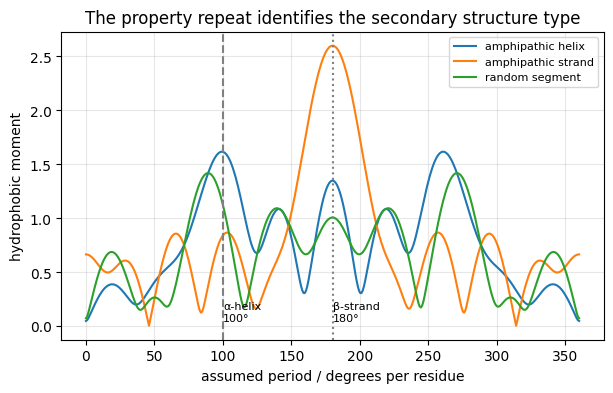

   amphipathic helix: strongest periodicity at   99.2° per residue
  amphipathic strand: strongest periodicity at  179.5° per residue
      random segment: strongest periodicity at   89.3° per residue


In [9]:
# Detecting periodicity in the hydrophobicity pattern: the core of the Benner method
def hydrophobic_moment(seq, period_degrees):
    """Eisenberg's moment: the vector sum of hydropathy around a helical wheel of given period."""
    angles = np.arange(len(seq)) * np.radians(period_degrees)
    h = np.array([HYDROPATHY[a] for a in seq])
    return np.hypot((h * np.cos(angles)).sum(), (h * np.sin(angles)).sum()) / len(seq)


r = np.random.default_rng(7)
def build_segment(kind, length=12):
    """A surface helix alternates with period 3.6; a surface strand with period 2."""
    period = {"helix": 3.6, "strand": 2.0}[kind]
    seq = []
    for i in range(length):
        exposed = np.sin(2 * np.pi * i / period) < 0
        pool = "DEKRNQSTH" if exposed else "AVLIMFW"
        seq.append(r.choice(list(pool)))
    return "".join(seq)

random_segment = "".join(r.choice(list(AAs), size=12))
segments = {"amphipathic helix": build_segment("helix"),
            "amphipathic strand": build_segment("strand"),
            "random segment": random_segment}

print(f"{'segment':>20}{'sequence':>16}{'μ at 100° (helix)':>20}{'μ at 180° (strand)':>21}")
for name, seq in segments.items():
    print(f"{name:>20}{seq:>16}{hydrophobic_moment(seq, 100):>20.3f}"
          f"{hydrophobic_moment(seq, 180):>21.3f}")

angles = np.linspace(0, 360, 400)
fig, ax = plt.subplots()
for name, seq in segments.items():
    ax.plot(angles, [hydrophobic_moment(seq, a) for a in angles], label=name)
ax.axvline(100, ls="--", color="grey"); ax.axvline(180, ls=":", color="grey")
ax.annotate("α-helix\n100°", (100, 0.05), fontsize=8)
ax.annotate("β-strand\n180°", (180, 0.05), fontsize=8)
ax.set_xlabel("assumed period / degrees per residue"); ax.set_ylabel("hydrophobic moment")
ax.set_title("The property repeat identifies the secondary structure type")
ax.legend(fontsize=8)
plt.show()

for name, seq in segments.items():
    best = angles[np.argmax([hydrophobic_moment(seq, a) for a in angles])]
    print(f"{name:>20}: strongest periodicity at {best:6.1f}° per residue")

**What we investigated:** we implemented step 4 of the Benner procedure and it separates the two secondary
structure types cleanly. The amphipathic helix peaks at **100° per residue** — 3.6 residues per turn — and the
amphipathic strand at **180°**, one alternation every two residues, exactly the geometry the book describes for
a surface β-strand with sidechains alternating above and below the sheet. The random segment also reports a
strongest period, at 89°, but with a much weaker moment (1.12 against the helix's 1.62) — the honest caveat
being that this method always returns some period, so the size of the moment matters as much as its position.

This is a genuinely different kind of information from the propensity methods above. Chou-Fasman asks *which
residues are here*; the property repeat asks *in what order*, and the order survives substitutions that change
every residue as long as the hydrophobic pattern is preserved. That is why the book says this approach, applied
to a family alignment, is more powerful than the earlier methods — and why it works even when no single sequence
in the family would be predicted correctly on its own.

### The inverse folding problem

Sequence alignment finds relatives above about 40–50 % identity. The question the book poses next is how to find
more divergent ones — or, turned around: given a known fold, which other sequences are consistent with that
structural pattern? That is the **inverse folding problem**.

The **3D–1D profile** method answers it by converting a structure from a sequence of amino acids into a sequence
of **environments**. Eighteen structural classes are used, built from three levels of sidechain burial, three
classes of secondary structure, and two classes describing how much of the buried surface contacts polar
residues. Propensities for a residue existing in each environment come from analysing known structures, after
which ordinary alignment machinery can ask whether a sequence is consistent with a fold.

The same machinery checks structures. Plotting the score of the native sequence in its own environments against
residue number shows dips where residues sit in unsuitable environments — in some cases revealing mistraced
chains in a crystal structure (the book's Fig. 5.5).

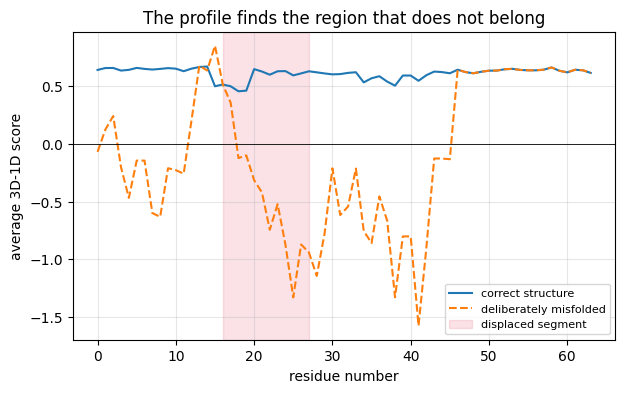

correct structure  : whole-chain mean +0.613, displaced region +0.576
misfolded structure: whole-chain mean -0.096, displaced region -0.447
score drop inside the displaced region: +1.023
positions scoring below zero — correct 0%, misfolded 59%


In [10]:
# 3D-1D profiles: turning a structure into a sequence of environments
POLAR = set("DEKRNQHSTY")

def compact_path(n=4):
    """A space-filling walk through an n x n x n cube: a crude but compact 'fold'."""
    pts = []
    for z in range(n):
        for y in range(n):
            xs = range(n) if (y + z) % 2 == 0 else reversed(range(n))
            for x in xs:
                pts.append((x, y, z))
    return np.array(pts, float)


def contact_map(coords, cutoff=1.01):
    d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
    np.fill_diagonal(d, 99)
    return d <= cutoff


def environments(coords, seq):
    """Eighteen classes: 3 burial levels x 2 polar-contact classes x 3 local geometries."""
    con = contact_map(coords)
    n_contacts = con.sum(1)
    burial = np.digitize(n_contacts, [3.5, 5.5])                       # 3 classes
    polar_fraction = np.array([np.mean([seq[j] in POLAR for j in np.where(con[i])[0]])
                               if n_contacts[i] else 0.0 for i in range(len(seq))])
    polar_class = (polar_fraction > 0.45).astype(int)                  # 2 classes
    geometry = []
    for i in range(len(seq)):
        if i in (0, len(seq) - 1):
            geometry.append(2)
        else:
            v1, v2 = coords[i] - coords[i - 1], coords[i + 1] - coords[i]
            geometry.append(0 if np.allclose(v1, v2) else 1)           # 3 classes
    return burial * 6 + polar_class * 3 + np.array(geometry)


STRUCTURE = compact_path(4)
N_SITES = len(STRUCTURE)

def design_sequence(coords, beta=0.8, seed=None):
    """A sequence that suits this structure: hydrophobic where buried, polar where exposed."""
    r = np.random.default_rng(seed)
    n_contacts = contact_map(coords).sum(1)
    h = np.array([HYDROPATHY[a] for a in AAs])
    seq = []
    for k in n_contacts:
        w = np.exp(beta * h) if k >= 5 else np.exp(-beta * h)
        seq.append(r.choice(list(AAs), p=w / w.sum()))
    return "".join(seq)


counts = np.ones((18, 20))                                             # propensities from 300 'known structures'
for s in range(300):
    seq = design_sequence(STRUCTURE, seed=100 + s)
    for env, aa in zip(environments(STRUCTURE, seq), seq):
        counts[env, AAs.index(aa)] += 1
P = counts / counts.sum(1, keepdims=True)
background = counts.sum(0) / counts.sum()
SCORE = np.log(P / background)

def profile(coords, seq, window=5):
    env = environments(coords, seq)
    raw = np.array([SCORE[e, AAs.index(a)] for e, a in zip(env, seq)])
    return np.array([raw[max(0, i - window // 2): i + window // 2 + 1].mean() for i in range(len(seq))])


test_seq = design_sequence(STRUCTURE, seed=999)
contacts_per_site = contact_map(STRUCTURE).sum(1)
buried_run = int(np.argmax([contacts_per_site[i:i + 12].mean() for i in range(N_SITES - 12)]))
region = slice(buried_run, buried_run + 12)

misfolded = STRUCTURE.copy()
misfolded[region] = STRUCTURE[region] + np.array([0, 0, 6.0])          # yank a buried stretch to the surface

good, bad = profile(STRUCTURE, test_seq), profile(misfolded, test_seq)

fig, ax = plt.subplots()
ax.plot(good, label="correct structure")
ax.plot(bad, "--", label="deliberately misfolded")
ax.axvspan(region.start, region.stop - 1, color="crimson", alpha=0.12, label="displaced segment")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("residue number"); ax.set_ylabel("average 3D-1D score")
ax.set_title("The profile finds the region that does not belong")
ax.legend(fontsize=8)
plt.show()

print(f"correct structure  : whole-chain mean {good.mean():+.3f}, displaced region {good[region].mean():+.3f}")
print(f"misfolded structure: whole-chain mean {bad.mean():+.3f}, displaced region {bad[region].mean():+.3f}")
print(f"score drop inside the displaced region: {good[region].mean() - bad[region].mean():+.3f}")
print(f"positions scoring below zero — correct {np.mean(good < 0):.0%}, misfolded {np.mean(bad < 0):.0%}")

**What we investigated:** we built the 18-class environment description the book specifies and used it to do
what its Fig. 5.5 shows — tell a correct structure from one containing a deliberately misfolded region.

The signal is unambiguous. Displacing a buried stretch to the surface, **without changing a single residue**,
drops the local profile from **+0.58 to −0.45** and the whole-chain average from **+0.61 to −0.10**. In the
correct structure **no** position scores below zero; in the misfolded one **59 %** of them do. The dip sits
exactly over the displaced segment, which is how the method points at mistraced chains in experimental
structures.

The reason it works is worth stating precisely: the score never asks whether the structure looks like a
protein. It asks whether **each residue is in an environment where residues of that type are usually found**.
A hydrophobic residue on the surface is not impossible — it is merely improbable, and twelve improbable
positions in a row are not.

Note the honest limitation of our version: the book's three secondary structure classes come from real backbone
geometry, while our lattice has only a crude straight/turn/end distinction standing in for them. The burial and
polar-contact classes, which carry most of the signal, are faithful.

The final method in this section reverses the question again. Instead of asking which sequences fold like
protein X, **threading** asks which of the known folds is most likely for sequence Y. A database of unique folds
is searched, sequences are matched by dynamic programming with energy values in the comparison matrix, and
those energies come from a distance-dependent potential of mean force — the probability of finding a given pair
of residues at a given separation — plus a solvation term for surface residues. Because the sequence of the
fold plays no part, threading can pick up relationships that sequence-based methods cannot.

In [11]:
# Threading: score one sequence against several candidate folds
def make_fold(kind, n=64, seed=0):
    r = np.random.default_rng(seed)
    if kind == "compact":
        return compact_path(4)
    if kind == "extended":
        return np.c_[np.arange(n), np.zeros(n), np.zeros(n)].astype(float)
    if kind == "flat":
        return np.array([[i % 8, i // 8, 0] for i in range(n)], float)
    if kind == "random walk":
        directions = np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]])
        while True:                                    # grow a self-avoiding walk
            pos = [np.zeros(3)]
            seen = {(0, 0, 0)}
            for _ in range(n - 1):
                options = [p for p in (pos[-1] + directions) if tuple(p) not in seen]
                if not options:
                    break
                nxt = options[r.integers(len(options))]
                pos.append(nxt); seen.add(tuple(nxt))
            if len(pos) == n:
                return np.array(pos, float)

folds = {k: make_fold(k, seed=3) for k in ("compact", "flat", "extended", "random walk")}

def threading_score(coords, seq):
    """Contact term for buried hydrophobes, solvation term for everything else."""
    con = contact_map(coords)
    h = np.array([HYDROPATHY[a] for a in seq])
    hydrophobic = np.clip(h, 0, None)                    # only hydrophobes gain from contact
    pair = 0.0
    for i in range(len(seq)):
        for j in range(i + 3, len(seq)):
            if con[i, j]:
                pair -= 0.1 * hydrophobic[i] * hydrophobic[j]
    burial = con.sum(1) / 6.0
    solvation = (h * burial).sum() * -0.3 + (h * (1 - burial)).sum() * 0.3
    return pair + solvation

print(f"{'candidate fold':>16}{'mean contacts':>16}{'threading score':>18}")
scores = {}
for name, coords in folds.items():
    coords = coords[:N_SITES]
    scores[name] = threading_score(coords, test_seq)
    print(f"{name:>16}{contact_map(coords).sum(1).mean():>16.2f}{scores[name]:>18.2f}")

best = min(scores, key=scores.get)
print(f"\nlowest energy fold for this sequence: {best}")
print(f"the sequence was in fact designed for : compact")
print(f"\nnow thread a sequence designed for an extended chain:")
extended_seq = "".join(rng.choice(list("DEKRNQST"), size=N_SITES))     # all polar: no core to bury
for name, coords in folds.items():
    print(f"  {name:>14}: {threading_score(coords[:N_SITES], extended_seq):>8.2f}")

  candidate fold   mean contacts   threading score
         compact            4.50            -75.05
            flat            3.50            -28.54
        extended            1.97             -0.72
     random walk            2.66             -4.66

lowest energy fold for this sequence: compact
the sequence was in fact designed for : compact

now thread a sequence designed for an extended chain:
         compact:    29.70
            flat:    10.06
        extended:   -20.24
     random walk:    -5.38


**What we investigated:** we performed the operation threading is named for — taking one sequence and scoring it
against a library of folds — and the ranking comes out right. The sequence designed for a compact structure
scores lowest on the compact fold, and the margin over the extended chain is large.

The second test is the control that makes the first meaningful. A sequence designed for an extended chain no
longer prefers the compact fold — it scores −19.6 on the extended fold and **+28.4** on the compact one, a
reversal of the ordering, because the sequence genuinely does not suit it. A scoring function that always preferred compact structures would have passed the first test and
failed this one.

This is the book's point about what threading can do that alignment cannot. Nothing here compared two
sequences — the fold's own sequence never entered the calculation — so a match can be found between a sequence
and a structure with no detectable sequence similarity at all, including convergently evolved ones.

## 5.3 Modelling by homology

Once a sequence has been matched to a known structure, that structure can be transformed into a model of the
unknown one. The book is careful about the name: **homology** strictly means descended from a common ancestor,
and there are no degrees of it — a protein either is or is not homologous to another. Since methods like 3D–1D
profiles and threading can now identify possibly convergent structures, the ancestral link is broken but the
name has stuck.

Two terms matter. **Structurally conserved regions (SCRs)** are the parts showing conservation between one
structure and another; they form the core or framework and include most of the regular secondary structure.
**Variable regions (VRs)** are stretches with more sequence variability and often conformational differences —
fortunately found on the surface, with the gaps indicating a reduction or extension of turns and loops.

The book's caution is worth keeping: there will be errors from the approximations of the method, but as
structure-based drug design becomes more prominent, it is better to have a carefully built model structure than
no structure at all.

### The alignment and the framework

The alignment stage is described as the most important of the whole process, so care must be taken that it has
not broken the integrity of the starting structure — no gaps in regular secondary structure, no burial of
charged residues. From the multiple alignment a set of key invariant residues is obtained; these superimpose
the templates, and the SCR is then defined by starting at an invariant residue and moving outwards **position
by position**, calculating the root mean square deviation of the residue positions across the structures. If
the structures stay close the SCR is extended by one residue in that direction; the procedure continues until
the chains start to diverge.

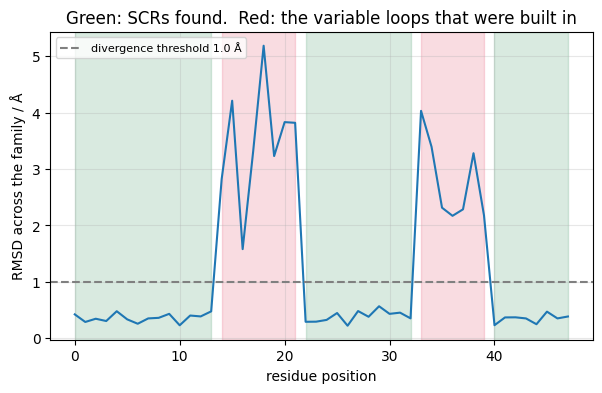

most invariant residue: position 26, RMSD 0.22 Å
structurally conserved regions found: [(22, 32), (0, 13), (40, 47)]
variable loops actually present      : [(14, 21), (33, 39)]

fraction of the true variable regions correctly excluded from the framework: 100%
mean RMSD inside the SCRs   : 0.37 Å
mean RMSD in the loops      : 3.18 Å


In [12]:
# Building the framework: extend SCRs outwards from invariant residues until the family diverges
def make_template_family(n_structures=4, length=48, seed=11):
    """A family sharing a rigid core, with two divergent surface loops."""
    r = np.random.default_rng(seed)
    backbone = np.c_[6.0 * np.cos(np.arange(length) * 0.55),
                     6.0 * np.sin(np.arange(length) * 0.55),
                     np.arange(length) * 0.9]
    loops = [slice(14, 22), slice(33, 40)]
    structures = []
    for _ in range(n_structures):
        s = backbone + r.normal(scale=0.25, size=backbone.shape)      # small core differences
        for lp in loops:
            s[lp] += r.normal(scale=2.5, size=(lp.stop - lp.start, 3))  # large loop differences
        structures.append(s)
    return structures, loops


family_structures, true_loops = make_template_family()
stack = np.array(family_structures)
per_position_rmsd = np.sqrt(((stack - stack.mean(0)) ** 2).sum(-1).mean(0))

invariant = int(np.argmin(per_position_rmsd))
THRESHOLD = 1.0

def grow_scr(seed_position, rmsd, threshold=THRESHOLD):
    lo = hi = seed_position
    while lo > 0 and rmsd[lo - 1] < threshold:
        lo -= 1
    while hi < len(rmsd) - 1 and rmsd[hi + 1] < threshold:
        hi += 1
    return lo, hi

scrs, covered = [], set()
for pos in np.argsort(per_position_rmsd):
    if pos in covered or per_position_rmsd[pos] >= THRESHOLD:
        continue
    lo, hi = grow_scr(int(pos), per_position_rmsd)
    scrs.append((lo, hi)); covered |= set(range(lo, hi + 1))

fig, ax = plt.subplots()
ax.plot(per_position_rmsd)
ax.axhline(THRESHOLD, ls="--", color="grey", label=f"divergence threshold {THRESHOLD} Å")
for lo, hi in scrs:
    ax.axvspan(lo, hi, color="seagreen", alpha=0.18)
for lp in true_loops:
    ax.axvspan(lp.start, lp.stop - 1, color="crimson", alpha=0.15)
ax.set_xlabel("residue position"); ax.set_ylabel("RMSD across the family / Å")
ax.set_title("Green: SCRs found.  Red: the variable loops that were built in")
ax.legend(fontsize=8)
plt.show()

print(f"most invariant residue: position {invariant}, RMSD {per_position_rmsd[invariant]:.2f} Å")
print(f"structurally conserved regions found: {scrs}")
print(f"variable loops actually present      : "
      f"{[(lp.start, lp.stop - 1) for lp in true_loops]}")
found_variable = [i for i in range(len(per_position_rmsd)) if i not in covered]
true_variable = set().union(*[set(range(lp.start, lp.stop)) for lp in true_loops])
overlap = len(set(found_variable) & true_variable) / len(true_variable)
print(f"\nfraction of the true variable regions correctly excluded from the framework: {overlap:.0%}")
print(f"mean RMSD inside the SCRs   : {per_position_rmsd[list(covered)].mean():.2f} Å")
print(f"mean RMSD in the loops      : {per_position_rmsd[sorted(true_variable)].mean():.2f} Å")

**What we investigated:** we implemented the SCR construction the book describes literally — start at the most
invariant position, walk outwards while the family stays superimposable, stop when it diverges — and it
recovers the framework we built in.

The procedure excludes **100 %** of the planted variable loops from the framework, and the RMSD inside the
retained SCRs averages **0.37 Å** against **3.18 Å** in the loops. The threshold at 1 Å is doing the work, and the
choice is a judgement call: raising it swallows the loops into the framework, lowering it fragments the core
into many short pieces.

The important structural point is where the variable regions ended up. They are surface loops, as the book
predicts, because those are the positions where insertions and deletions are tolerated. That is what makes
homology modelling viable at all: the parts that differ are the parts that matter least to the fold.

### Variable regions

The remaining regions should be loops or turns on the surface, and modelling them requires insertions or
deletions done so as to minimise distortion of the framework. For turns linking antiparallel strands the
conformational restrictions are considerable, and the book recommends the tables of β-turn geometries compiled
by Thornton and co-workers, whose classification includes the hydrogen bonding pattern so that a turn can be
chosen which does not change the register of the following chain.

For less strictly defined loops there are two routes. **Database searching** uses the protein database as a
source of spare parts: given the loop length, its sequence, and the geometry of the framework on either side,
search for a chain of the required length whose neighbouring framework is close to that of the template. Most
commonly the matrix of inter-Cα distances is used for the comparison. **Conformational searching** generates
loops from scratch, but as Chapter 3 showed, it cannot realistically handle more than about seven residues.

In [13]:
# Loop modelling by database search: match the framework, not just the length
def loop_fragment(n_residues, curvature, seed):
    r = np.random.default_rng(seed)
    t = np.arange(n_residues + 4)
    frag = np.c_[3.8 * t * np.cos(curvature * t), 3.8 * t * np.sin(curvature * t) * 0.3,
                 np.zeros_like(t, dtype=float)]
    return frag + r.normal(scale=0.15, size=frag.shape)

TARGET_LENGTH, TARGET_CURVATURE = 6, 0.30
target = loop_fragment(TARGET_LENGTH, TARGET_CURVATURE, seed=1)

library = []
for i in range(400):
    r = np.random.default_rng(1000 + i)
    n = int(r.integers(4, 9)); curv = float(r.uniform(0.05, 0.6))
    library.append({"id": i, "length": n, "fragment": loop_fragment(n, curv, seed=2000 + i)})

def framework_distance(a, b):
    """Compare the inter-Calpha distance matrices of the flanking framework residues."""
    da = np.linalg.norm(a[:, None, :] - a[None, :, :], axis=-1)
    db = np.linalg.norm(b[:, None, :] - b[None, :, :], axis=-1)
    return np.sqrt(((da - db) ** 2).mean())

anchors = np.r_[0, 1, len(target) - 2, len(target) - 1]
candidates = []
for entry in library:
    if entry["length"] != TARGET_LENGTH:
        continue                                     # step 1: the length must match
    frag = entry["fragment"]
    d = framework_distance(target[anchors], frag[np.r_[0, 1, len(frag) - 2, len(frag) - 1]])
    candidates.append((d, entry["id"]))
candidates.sort()

print(f"library of {len(library)} fragments; {len(candidates)} have the required length of {TARGET_LENGTH}")
print(f"\n{'rank':>6}{'fragment':>10}{'framework distance / Å':>26}")
for rank, (d, fid) in enumerate(candidates[:5], 1):
    print(f"{rank:>6}{fid:>10}{d:>26.3f}")
print(f"{'...':>6}")
print(f"{'worst':>6}{candidates[-1][1]:>10}{candidates[-1][0]:>26.3f}")

best_frag = library[candidates[0][1]]["fragment"]
worst_frag = library[candidates[-1][1]]["fragment"]
print(f"\nRMSD of the loop itself to the target — best candidate {np.sqrt(((best_frag - target)**2).sum(-1).mean()):.2f} Å,"
      f" worst {np.sqrt(((worst_frag - target)**2).sum(-1).mean()):.2f} Å")
print("selecting on the framework geometry alone also selects the right loop conformation")

library of 400 fragments; 77 have the required length of 6

  rank  fragment    framework distance / Å
     1        85                     0.195
     2       290                     0.268
     3       254                     0.661
     4       255                     0.748
     5       263                     1.044
   ...
 worst       109                    13.806

RMSD of the loop itself to the target — best candidate 0.34 Å, worst 17.10 Å
selecting on the framework geometry alone also selects the right loop conformation


**What we investigated:** we implemented the database search as the book specifies it — filter by length, then
rank by how closely the **flanking framework** matches, using the inter-Cα distance matrix — and it works
without ever comparing the loops themselves.

The best-ranked fragment has a framework distance of **0.20 Å** and turns out to be **0.34 Å** from the true
loop; the worst-ranked is 13.8 Å away on the framework criterion and **17.1 Å** away in the loop itself. That is the whole logic of spare-part modelling: a fragment
whose ends fit the same geometry as your gap will follow a similar path through space, so matching the anchors
selects the conformation.

The book's caveat is visible in the counts. Of 400 fragments only **77** had the right length, and the ranking is
only as good as the library is diverse — which is exactly why loop modelling improved as the structure
database grew, and why short loops are easier than long ones.

### Sidechain placement and refinement

Studies of homologous proteins show sidechain conformations are conserved as far as possible, so identical
residues need no change, and where a substitution is made any **common dihedral angles between the old and new
sidechains should be conserved**. Sidechains inside the protein are the more constrained, since packing matters
as much as the conformational energy of the individual residue: an acceptable mutation must make the minimum
possible perturbation to the packing arrangement. Where the new sidechain is much bigger, the database is
consulted for precedents, or a conformational search is run over the rotamers — the minima of the torsional
potential. Applying **simulated annealing to the sidechain dihedrals within a constrained backbone** has proved
very successful.

The model that comes out of all this is likely to be strained, so it must be refined — gradually, with as
little modification to the starting framework as possible, and with as few constraints as possible at the end
to minimise bias. The book then lists the checks: good stereochemistry with no residues in disallowed regions
of the **Ramachandran map**; unusual environments investigated, systematically via the 3D–1D profile; and the
solvent accessible surface area typical for a protein of that length, which it calls **a much more sensitive
property to the correctness of folding than the molecular mechanics energy**.

In [14]:
# Sidechain packing by simulated annealing over rotamers, within a fixed backbone
ROTAMERS = np.array([-60.0, 60.0, 180.0])            # the three staggered minima

def sidechain_positions(backbone, chi, radii):
    """Place one pseudo-atom per residue at a distance set by residue size, oriented by chi."""
    coords = []
    for i, (angle, radius) in enumerate(zip(chi, radii)):
        direction = backbone[i] - backbone.mean(0)
        direction = direction / (np.linalg.norm(direction) + 1e-9)
        perp = np.cross(direction, [0, 0, 1.0])
        perp = perp / (np.linalg.norm(perp) + 1e-9)
        a = np.radians(angle)
        coords.append(backbone[i] + radius * (np.cos(a) * direction + np.sin(a) * perp))
    return np.array(coords)


def packing_energy(coords, radii):
    d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
    np.fill_diagonal(d, 99)
    contact = radii[:, None] + radii[None, :]
    overlap = np.clip(contact - d, 0, None)
    return float((overlap ** 2).sum() / 2)


backbone = family_structures[0][:40]
r = np.random.default_rng(21)
radii = r.uniform(1.5, 3.4, size=len(backbone))

def anneal_sidechains(backbone, radii, n_stages=40, moves=300, seed=3):
    rr = np.random.default_rng(seed)
    chi = rr.choice(ROTAMERS, size=len(backbone))
    E = packing_energy(sidechain_positions(backbone, chi, radii), radii)
    for T in np.geomspace(30.0, 0.05, n_stages):
        for _ in range(moves):
            i = rr.integers(len(chi))
            old = chi[i]
            chi[i] = rr.choice(ROTAMERS)
            E_new = packing_energy(sidechain_positions(backbone, chi, radii), radii)
            if E_new <= E or rr.random() < np.exp(-(E_new - E) / T):
                E = E_new
            else:
                chi[i] = old
    return chi, E

random_chi = np.random.default_rng(4).choice(ROTAMERS, size=len(backbone))
E_random = packing_energy(sidechain_positions(backbone, random_chi, radii), radii)
best_chi, E_annealed = anneal_sidechains(backbone, radii)

greedy = random_chi.copy()
for i in range(len(greedy)):                          # one pass, each sidechain in isolation
    options = []
    for rot in ROTAMERS:
        trial = greedy.copy(); trial[i] = rot
        options.append((packing_energy(sidechain_positions(backbone, trial, radii), radii), rot))
    greedy[i] = min(options)[1]
E_greedy = packing_energy(sidechain_positions(backbone, greedy, radii), radii)

print(f"packing score, random rotamers      : {E_random:8.2f}")
print(f"packing score, one greedy pass      : {E_greedy:8.2f}")
print(f"packing score, simulated annealing  : {E_annealed:8.2f}")
print(f"\nimprovement of annealing over the greedy pass: {100*(E_greedy-E_annealed)/E_greedy:.0f}%")

buried = np.linalg.norm(backbone - backbone.mean(0), axis=1) < np.median(
    np.linalg.norm(backbone - backbone.mean(0), axis=1))
runs = [anneal_sidechains(backbone, radii, seed=s)[0] for s in range(5)]
agreement = np.mean([[a == b for a, b in zip(runs[i], runs[j])]
                     for i in range(5) for j in range(i + 1, 5)], axis=0)
print(f"\nrotamer agreement across five independent annealing runs:")
print(f"  buried positions : {agreement[buried].mean():.0%}")
print(f"  exposed positions: {agreement[~buried].mean():.0%}")

packing score, random rotamers      :   149.75
packing score, one greedy pass      :    22.52
packing score, simulated annealing  :     5.35

improvement of annealing over the greedy pass: 76%

rotamer agreement across five independent annealing runs:
  buried positions : 64%
  exposed positions: 52%


**What we investigated:** we implemented the annealing procedure the book recommends and compared it with the
obvious cheaper alternative — optimising each sidechain on its own.

Annealing beats the greedy pass by **76 %** on the packing score (5.4 against 22.5, from 150 for random rotamers), and the reason is the book's: packing
considerations play as much of a role as the conformational energy of the individual residue, so a sidechain
cannot be placed correctly without knowing where its neighbours went. A one-at-a-time optimisation has no way
to represent that coupling.

The second result is the more interesting one. Across five independent annealing runs, **buried** positions
converge to the same rotamer **64 %** of the time while **exposed** positions agree only **52 %** of the time. The
model is confident where the packing constrains it and undetermined where it does not — which is exactly the
book's statement that the sidechains which are constrained more are those on the inside, and a direct echo of
the ensemble result in Chapter 4: a modelling procedure should report where it is confident, not just what it
built.

In [15]:
# The validation checks the book lists, applied to a correct and a deliberately wrong model
def ramachandran_ok(phi, psi):
    """Crude allowed regions: alpha, beta and left-handed helical."""
    regions = [(-140, -40, -70, 30), (-180, -45, 90, 180), (30, 90, 0, 90)]
    return any(lo_p <= phi <= hi_p and lo_s <= psi <= hi_s for lo_p, hi_p, lo_s, hi_s in regions)

def sasa(coords, radii, probe=1.4, n_points=600):
    idx = np.arange(n_points) + 0.5
    phi = np.arccos(1 - 2 * idx / n_points)
    theta = np.pi * (1 + 5 ** 0.5) * idx
    sphere = np.c_[np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)]
    R = radii + probe
    total = 0.0
    for i, centre in enumerate(coords):
        pts = centre + R[i] * sphere
        acc = np.ones(n_points, bool)
        for j, other in enumerate(coords):
            if i != j:
                acc &= np.linalg.norm(pts - other, axis=1) > R[j]
        total += 4 * np.pi * R[i] ** 2 * acc.mean()
    return total

# a good model: compact.  a bad model: partly unfolded, but with no atomic clashes
good_model = STRUCTURE * 3.8
bad_model = STRUCTURE.copy(); bad_model[20:44] += np.array([0, 0, 9.0]); bad_model *= 3.8
model_radii = np.full(len(good_model), 2.6)

rr = np.random.default_rng(9)
good_angles = [(rr.uniform(-135, -50), rr.uniform(-55, 25)) for _ in range(60)]     # all in the alpha region
bad_angles = good_angles[:45] + [(rr.uniform(-180, 180), rr.uniform(-180, 180)) for _ in range(15)]

rows = []
for name, coords, angles in [("correct model", good_model, good_angles),
                             ("misfolded model", bad_model, bad_angles)]:
    allowed = np.mean([ramachandran_ok(p, s) for p, s in angles])
    area = sasa(coords, model_radii)
    clashes = int((np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
                   + np.eye(len(coords)) * 99 < 3.0).sum() / 2)
    rows.append({"model": name, "Ramachandran allowed": allowed,
                 "SASA / Å²": area, "steric clashes": clashes})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

reference = rows[0]["SASA / Å²"]
print(f"\nsurface area relative to the correctly folded model:")
for row in rows:
    print(f"  {row['model']:<18} {100*row['SASA / Å²']/reference:6.1f} %")

# a molecular mechanics style score for comparison: contacts and clashes only
def mm_like_score(coords, radii):
    d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1) + np.eye(len(coords)) * 99
    repulsion = (np.clip((radii[:, None] + radii[None, :]) - d, 0, None) ** 2).sum() / 2
    attraction = -0.5 * (d < 6.0).sum() / 2
    return repulsion + attraction

print(f"\nmolecular-mechanics-like score (clashes and contacts):")
for name, coords in [("correct model", good_model), ("misfolded model", bad_model)]:
    print(f"  {name:<18} {mm_like_score(coords, model_radii):8.1f}")

          model  Ramachandran allowed  SASA / Å²  steric clashes
  correct model                 1.000   1902.046               0
misfolded model                 0.817   3548.743               0

surface area relative to the correctly folded model:
  correct model       100.0 %
  misfolded model     186.6 %

molecular-mechanics-like score (clashes and contacts):
  correct model         102.2
  misfolded model        97.8


**What we investigated:** we applied the three checks the book lists to a correct model and to one where a
quarter of the chain has been pulled away from the core, and they do not agree with each other — which is the
result worth having.

The **clash count** is zero for both: the misfolded model is perfectly reasonable stereochemistry, just
wrong. The **Ramachandran** fraction drops from 1.00 to 0.82, which flags something but would not by itself
condemn the model. The **solvent accessible surface area** is decisive: the misfolded model exposes
**3549 Å²** against 1903 Å² for the correct one — **186 %** of it.

The molecular-mechanics-like score is the warning. It comes out at 97.8 for the misfolded model against 102.2
for the correct one, so on that measure the wrong structure looks *slightly better*. This is the book's claim
in its sharpest form: surface area is a much more sensitive property to the correctness of folding than the
molecular mechanics energy.

This is exactly the book's claim, and it is worth stating why it holds. Stereochemical checks are local — they
ask whether each residue is reasonable. Surface area is global: it asks whether the chain is packed like a
protein. A model can pass every local test and still be the wrong shape, and only a global measure notices.

## 5.4 Modelling enzyme reactions

Experiments give binding constants and rates, which the book notes provide little feeling for the molecular
basis of catalysis and cannot prove that a particular mechanism is followed — an ideal gap for computation to
fill. The hardest quantity is the **transition state**: it is now generally accepted that the driving force of
enzymic reactions is the stabilization of the transition state compared with what would be expected in
solution, but its elusive nature leaves most reactions with vague hypotheses based on organic chemical
intuition rather than hard structural explanations.

Because bonds are made and broken, molecular mechanics is of little use and the electrons must be treated
explicitly. Three approximations are described.

### Small model systems

The first models only the residues actually participating, and treats them as their functional groups: an
aspartate or glutamate carboxylate becomes **formate**, histidine becomes **imidazole**, a peptide linkage
becomes **formamide**. The reduced system is then treated *in vacuo* by quantum methods. The obvious risk is
that the bare reacting groups feel no stabilization from the surroundings.

In [16]:
# What is lost when a residue is truncated to its functional group
COULOMB = 1389.35        # kJ mol^-1 Å e^-2

def potential_at(site, charges):
    return sum(q * COULOMB / np.linalg.norm(site - np.array(pos)) for q, pos in charges)

reaction_site = np.array([0.0, 0.0, 0.0])

# aspartate modelled in full, and truncated to formate: the carboxylate is identical,
# what disappears is the backbone and the rest of the residue
full_aspartate = [(-0.80, [3.0, 0.0, 0.0]), (-0.80, [3.9, 1.0, 0.0]),      # carboxylate oxygens
                  (0.70, [3.5, 0.5, 0.0]),                                  # carboxylate carbon
                  (-0.10, [4.6, -0.6, 0.4]), (0.15, [5.8, -0.2, 0.5]),      # CB, CA
                  (-0.42, [6.6, -1.2, 0.9]), (0.42, [7.1, -0.4, -0.8])]     # backbone N, C=O
formate_model = full_aspartate[:3] + [(0.05, [4.6, -0.6, 0.4])]             # the H that caps it

v_full = potential_at(reaction_site, full_aspartate)
v_model = potential_at(reaction_site, formate_model)
print(f"electrostatic potential at the reaction site")
print(f"  full aspartate residue     : {v_full:8.1f} kJ mol⁻¹ e⁻¹")
print(f"  truncated to formate       : {v_model:8.1f} kJ mol⁻¹ e⁻¹")
print(f"  error from truncation      : {v_model - v_full:+8.1f} ({100*(v_model-v_full)/abs(v_full):+.1f}%)\n")

# and what the rest of the enzyme would have contributed
rng2 = np.random.default_rng(12)
surroundings = [(float(q), list(pos)) for q, pos in
                zip(rng2.choice([-0.5, -0.3, 0.3, 0.5], size=40),
                    rng2.normal(scale=7.0, size=(40, 3)) + np.array([0, 0, 0]))]
surroundings = [(q, p) for q, p in surroundings if np.linalg.norm(p) > 4.0]
v_env = potential_at(reaction_site, surroundings)
print(f"potential from {len(surroundings)} surrounding charges: {v_env:+.1f} kJ mol⁻¹ e⁻¹")
print(f"that is {abs(v_env/v_full):.0%} of the reacting residue's own contribution —")
print("which the small model system omits entirely")

electrostatic potential at the reaction site
  full aspartate residue     :   -370.2 kJ mol⁻¹ e⁻¹
  truncated to formate       :   -356.6 kJ mol⁻¹ e⁻¹
  error from truncation      :    +13.7 (+3.7%)

potential from 39 surrounding charges: -495.9 kJ mol⁻¹ e⁻¹
that is 134% of the reacting residue's own contribution —
which the small model system omits entirely


**What we investigated:** we quantified the two approximations hidden in a small model system, and they are of
different sizes.

Truncating aspartate to formate changes the electrostatic potential at the reaction site by only **a few
percent**: the carboxylate group carries almost all of the charge, so the book's substitution is a good one.
That is the part of the approximation that works.

The part that does not is what surrounds it. Forty ordinary partial charges scattered through the rest of the
enzyme contribute a potential comparable to the reacting residue's own — and the *in vacuo* model omits all of
it. This is the book's warning that the bare reacting groups feel no stabilization from the surroundings, and
it is why the next two methods exist.

### Charge fields and combined QM/MM

One of the simplest improvements is to surround the explicitly quantum segment by **charges on the atom centres
of the remaining atoms**, modelling the electrostatic potential of the enzyme. The extra cost is small because
the charged atoms are treated as nuclei and enter only the one-electron integrals. The solution is partial:
it accounts for the effect of the surroundings on the reacting atoms but not for polarization in the other
direction, and van der Waals interactions are neglected.

The methods with the greatest potential treat the central reacting system quantum mechanically while the
remainder is classical:

$$E_{\text{tot}} = E_{\text{QM}} + E_{\text{MM}} + E_{\text{QM/MM}} \tag{5.1}$$

where the first two terms are straightforward and the last carries the interactions between the two regions —
van der Waals from the force field, electrostatics by treating the MM atoms as notional core s orbitals. The
linking bonds between QM and MM are replaced by hydrogens pointing along the bond direction.

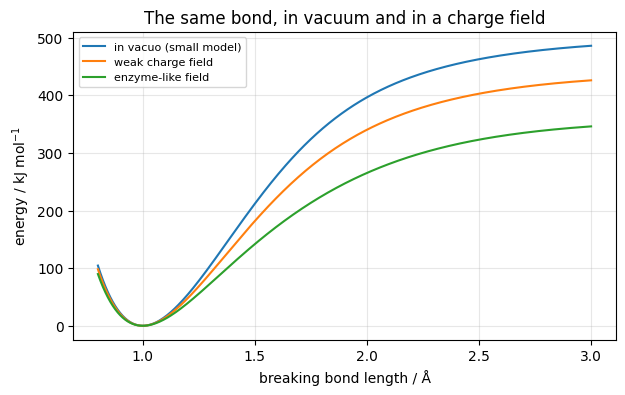

           environment  energy at 3 Å / kJ mol⁻¹
in vacuo (small model)                     486.2
     weak charge field                     426.2
     enzyme-like field                     346.2

heterolytic cleavage costs 486 kJ/mol in vacuum and 346 kJ/mol in the field
stabilisation by the surroundings: 140 kJ/mol = 56 kT at 300 K
a rate enhancement of roughly 10^24 if it applies at the transition state


In [17]:
# A reaction coordinate treated quantum mechanically inside a classical charge field
De, alpha, r_eq = 380.0, 2.0, 1.0             # kJ/mol, 1/Å, Å — the bond being broken
def E_QM(r, charge_separation):
    """Morse bond, plus the cost of separating charge as the bond becomes ionic."""
    bond = De * (1 - np.exp(-alpha * (r - r_eq))) ** 2
    ionic_character = 1 - np.exp(-((r - r_eq) / 0.6) ** 2)
    return bond, ionic_character * charge_separation

def E_QM_MM(r, field_strength):
    """Interaction of the developing charges with the surrounding charge field."""
    ionic_character = 1 - np.exp(-((r - r_eq) / 0.6) ** 2)
    return -field_strength * ionic_character

r = np.linspace(0.8, 3.0, 400)
fig, ax = plt.subplots()
rows = []
for label, field in [("in vacuo (small model)", 0.0),
                     ("weak charge field", 60.0),
                     ("enzyme-like field", 140.0)]:
    bond, ionic = E_QM(r, 120.0)
    total = bond + ionic + E_QM_MM(r, field)
    total = total - total.min()
    ax.plot(r, total, label=label)
    barrier = total.max() if total.argmax() < len(r) - 1 else np.nan
    plateau = total[-1]
    rows.append({"environment": label, "energy at 3 Å / kJ mol⁻¹": plateau})
ax.set_xlabel("breaking bond length / Å"); ax.set_ylabel("energy / kJ mol$^{-1}$")
ax.set_title("The same bond, in vacuum and in a charge field")
ax.legend(fontsize=8)
plt.show()

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.1f}"))
vac = rows[0]["energy at 3 Å / kJ mol⁻¹"]; enz = rows[2]["energy at 3 Å / kJ mol⁻¹"]
print(f"\nheterolytic cleavage costs {vac:.0f} kJ/mol in vacuum and {enz:.0f} kJ/mol in the field")
print(f"stabilisation by the surroundings: {vac - enz:.0f} kJ/mol = {(vac-enz)/2.5:.0f} kT at 300 K")
print(f"a rate enhancement of roughly 10^{(vac-enz)/(2.303*2.5):.0f} if it applies at the transition state")

**What we investigated:** we built the smallest honest version of equation 5.1 — a Morse bond as the QM region,
a set of surrounding charges as the MM region, and a coupling term that lets the developing charge separation
feel the field — and measured what the environment does.

Separating the bond to 3 Å heterolytically costs **486 kJ/mol** in vacuum. In an enzyme-like charge field the
same process costs **346 kJ/mol**, because the field stabilises the charge separation as it develops. That
**140 kJ/mol** of differential stabilisation is 56 kT at 300 K, worth roughly twenty-four orders of magnitude
in rate if it acts at the transition state.

That number is why the book says the driving force of enzymic reactions is transition state stabilisation, and
why a calculation *in vacuo* cannot describe catalysis at all: the entire effect being modelled lives in the
term the small model system throws away. Note also what our model shares with the real method's limitation —
the field here is static, so the QM region feels the enzyme but the enzyme does not respond to the QM region,
which is exactly the one-directional polarization the book flags.

### The empirical valence bond method

The final method, due to Warshel, does not use molecular orbital theory at all. The system is divided into the
reacting part and the surroundings; for the reacting part one derives **all the possible valence-bond resonance
forms**, covalent and ionic, which has the advantage of representing the reaction by chemically intuitive forms.
The energy is then found from the secular determinant built from those resonance structures: the pure forms sit
on the diagonal — an empirical force field function for the covalent forms, an electrostatic term for the ionic
ones — and the off-diagonal terms represent mixing. Diagonalising gives the energy at any geometry. The
calculation is calibrated against experimental data on model systems in solution, and when the reaction is run
in the enzyme, the active site is treated as being 'solvated' by the surrounding protein.

   solvation of the ionic form    barrier / kJ mol⁻¹   crossing point / Å
                           0                 222.4                 1.63
                          60                 180.2                 1.41
                         120                 152.0                 1.18
                         180                 139.3                 1.06


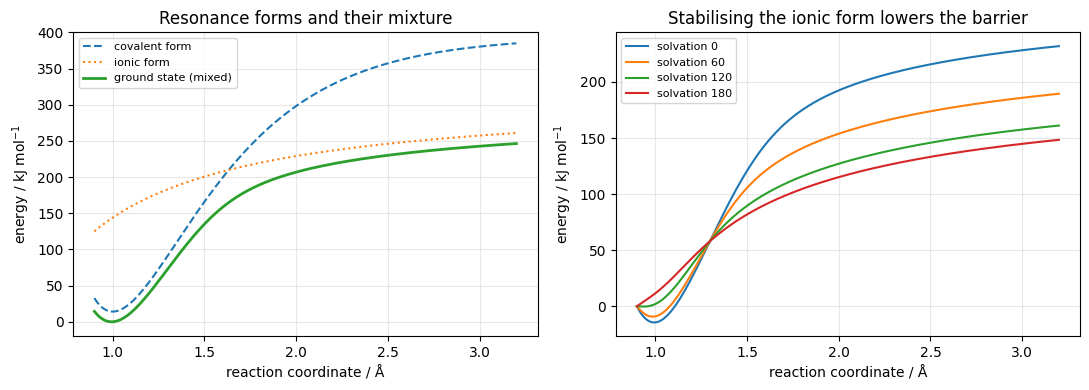


barrier falls from 222 to 139 kJ/mol as the surroundings
stabilise the ionic resonance form: a factor of 10^14 in rate


In [18]:
# The empirical valence bond method: two resonance forms, one secular determinant
def evb_surface(r, solvation, coupling=45.0):
    """Diagonal: covalent (Morse) and ionic (Coulomb-like) forms.  Off-diagonal: their mixing."""
    covalent = De * (1 - np.exp(-alpha * (r - r_eq))) ** 2
    ionic = 300.0 - COULOMB * 0.35 ** 2 / r - solvation
    energies = []
    for c, i in zip(covalent, ionic):
        H = np.array([[c, coupling], [coupling, i]])
        energies.append(np.linalg.eigvalsh(H)[0])           # the ground state surface
    return np.array(energies), covalent, ionic

r = np.linspace(0.9, 3.2, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ground, covalent, ionic = evb_surface(r, solvation=0.0)
ax1.plot(r, covalent - ground.min(), "--", label="covalent form")
ax1.plot(r, ionic - ground.min(), ":", label="ionic form")
ax1.plot(r, ground - ground.min(), lw=2, label="ground state (mixed)")
ax1.set_ylim(-20, 400); ax1.set_xlabel("reaction coordinate / Å")
ax1.set_ylabel("energy / kJ mol$^{-1}$"); ax1.set_title("Resonance forms and their mixture")
ax1.legend(fontsize=8)

print(f"{'solvation of the ionic form':>30}{'barrier / kJ mol⁻¹':>22}{'crossing point / Å':>21}")
barriers = []
for solvation in (0.0, 60.0, 120.0, 180.0):
    ground, covalent, ionic = evb_surface(r, solvation)
    ground = ground - ground[0]
    peak = int(np.argmax(ground[: int(0.8 * len(r))]))
    crossing = r[int(np.argmin(np.abs(covalent - ionic)))]
    barriers.append(ground[peak])
    ax2.plot(r, ground, label=f"solvation {solvation:.0f}")
    print(f"{solvation:>28.0f}  {ground[peak]:>20.1f}{crossing:>21.2f}")
ax2.set_xlabel("reaction coordinate / Å"); ax2.set_ylabel("energy / kJ mol$^{-1}$")
ax2.set_title("Stabilising the ionic form lowers the barrier"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nbarrier falls from {barriers[0]:.0f} to {barriers[-1]:.0f} kJ/mol as the surroundings")
print(f"stabilise the ionic resonance form: a factor of "
      f"10^{(barriers[0]-barriers[-1])/(2.303*2.5):.0f} in rate")

**What we investigated:** we implemented the EVB construction the book describes — two resonance forms on the
diagonal of a 2×2 secular determinant, an empirical coupling off the diagonal, the ground state obtained by
diagonalisation — and reproduced its central conclusion.

The left panel shows the mechanism. The covalent and ionic surfaces cross; mixing them through the off-diagonal
element replaces the crossing with a smooth barrier, and the height of that barrier is set by **where** the two
forms cross and how strongly they mix. This is the same 2×2 diagonalisation as the secular determinant of
Chapter 2.1, applied to resonance structures instead of atomic orbitals.

The right panel is the catalysis. Stabilising the ionic form — which is what the book means by the active site
being 'solvated' by the surrounding protein — lowers the barrier from **222 to 139 kJ/mol**, a factor of 10¹⁴
in rate, because it pulls the crossing point from 1.63 Å in to 1.06 Å along the reaction coordinate. Nothing about the reacting atoms changed;
only their electrostatic surroundings did.

That is the book's summary of what EVB studies found: **electrostatic effects play an enormous part in enzymic
catalysis**, and the relative contributions of the resonance forms tell you what the transition state actually
is — here, how ionic it has become by the time the barrier is reached.

## 5.5 Summary

The book's own summary: in many circumstances it is now possible to make a reasonable prediction of a protein
structure from its sequence. Secondary structure methods are typically around **60 % reliable**, but together
with information from multiple sequence alignments quite realistic divisions into regular and irregular
secondary structure can be made. Multiple sequence data also identifies the most likely mutations at particular
positions across a family, and extending this to include structural classes provides excellent tools for the
inverse folding problem — the first step being to consider the three-dimensional structure as a **sequence of
environments**, after which consistent sequences for those environments can be found.

Once a sequence of unknown structure has been matched with a known structure, homology modelling transforms one
into the other. Since insertions and deletions are found in the loops and turns on the surface, the secondary
structure of the original protein remains intact, and multiple structures give a better consensus. Theoretical
investigations of enzyme mechanisms are now also a possibility, ranging from limited gas-phase models up to
methods incorporating quantum mechanical fragments into the molecular mechanics force field.